# 02 - Exploratory Data Analysis (EDA)
Steel Temperature Prediction Project

This notebook analyzes the cleaned dataset and identifies opportunities to improve model performance.

In [1]:
print("Notebook is working!")

Notebook is working!


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10,5)

DATA_PATH = Path("../data/cleaned_data.xlsx")
TARGET = "LF2T40_TEMP_DROP"

df = pd.read_excel(DATA_PATH)

print(f"Shape: {df.shape}")
df.head()


Shape: (3643, 19)


,HEAT_ID,LF_LAST_TEMP_TIME,CAST_START,T40_TIME,LFTEMP_CASTSTART_DUR,CASTSTART_TO_T40_DUR,LFTEMP_T40_DUR,LIQ_TEMP,LF_LAST_TEMP,LADLE_LIFE,TAT,LF2T40_TEMP_DROP,T40_TEMP,TOTAL_PROCESS_TIME,SUPERHEAT,LF_TO_TOTAL_TIME_RATIO,CAST_TO_TOTAL_TIME_RATIO,LADLE_LIFE_PER_HOUR,SUPERHEAT_PER_MIN
0,M89062,2025-11-29 11:16:55,2025-11-29 11:33:19,2025-11-29 11:42:28,16,9,26,1509,1579,103,106.92,45,1534,25,70,0.615385,0.346154,57.800224,2.800000
1,M89067,2025-11-29 12:49:52,2025-11-29 13:09:58,2025-11-29 13:33:18,20,23,43,1510,1567,31,112.68,27,1540,43,57,0.465116,0.534884,16.506922,1.325581
2,M89070,2025-11-29 13:39:16,2025-11-29 13:57:38,2025-11-29 14:13:09,18,16,34,1506,1575,14,182.67,29,1546,34,69,0.529412,0.470588,4.598456,2.029412
3,M89069,2025-11-29 14:32:05,2025-11-29 14:44:58,2025-11-29 15:04:58,13,20,33,1511,1575,48,162.50,29,1546,33,64,0.393939,0.606061,17.723077,1.939394
4,M89073,2025-11-29 15:07:27,2025-11-29 15:33:58,2025-11-29 15:56:19,27,22,49,1508,1574,104,101.72,37,1537,49,66,0.551020,0.448980,61.344868,1.346939


## Dataset Overview

In [3]:
df.info()
display(df.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 3643 entries, 0 to 3642
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   HEAT_ID                   3643 non-null   str           
 1   LF_LAST_TEMP_TIME         3643 non-null   datetime64[us]
 2   CAST_START                3643 non-null   datetime64[us]
 3   T40_TIME                  3643 non-null   datetime64[us]
 4   LFTEMP_CASTSTART_DUR      3643 non-null   int64         
 5   CASTSTART_TO_T40_DUR      3643 non-null   int64         
 6   LFTEMP_T40_DUR            3643 non-null   int64         
 7   LIQ_TEMP                  3643 non-null   int64         
 8   LF_LAST_TEMP              3643 non-null   int64         
 9   LADLE_LIFE                3643 non-null   int64         
 10  TAT                       3643 non-null   float64       
 11  LF2T40_TEMP_DROP          3643 non-null   int64         
 12  T40_TEMP                  3643 

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
HEAT_ID,3643,3621,M89662,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LF_LAST_TEMP_TIME,3643,NaN,NaN,NaN,2026-02-27 14:38:31.865221,2025-11-29 11:16:55,2026-01-15 16:40:11.500000,2026-02-28 09:56:22,2026-04-11 08:20:34,2026-05-28 09:59:31,NaN
CAST_START,3643,NaN,NaN,NaN,2026-02-27 14:57:20.313203,2025-11-29 11:33:19,2026-01-15 16:53:19.500000,2026-02-28 10:15:42,2026-04-11 08:42:51,2026-05-28 10:16:02,NaN
T40_TIME,3643,NaN,NaN,NaN,2026-02-27 15:12:25.990392,2025-11-29 11:42:28,2026-01-15 17:13:29,2026-02-28 10:35:42,2026-04-11 08:51:06,2026-05-28 10:30:12,NaN
LFTEMP_CASTSTART_DUR,3643.0,NaN,NaN,NaN,18.811694,-317.0,14.0,18.0,22.0,470.0,20.54215
CASTSTART_TO_T40_DUR,3643.0,NaN,NaN,NaN,15.105957,-222.0,12.0,15.0,18.0,68.0,10.258481
LFTEMP_T40_DUR,3643.0,NaN,NaN,NaN,33.897886,-310.0,27.5,33.0,39.0,483.0,22.877884
LIQ_TEMP,3643.0,NaN,NaN,NaN,1505.32583,1462.0,1505.0,1505.0,1505.0,1526.0,1.617301
LF_LAST_TEMP,3643.0,NaN,NaN,NaN,1583.887181,1521.0,1578.0,1583.0,1589.0,1634.0,9.813509
LADLE_LIFE,3643.0,NaN,NaN,NaN,60.668954,1.0,33.0,60.0,89.0,161.0,33.24455


## Missing Values

In [4]:
missing = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Percent": (df.isna().mean()*100).round(2)
}).sort_values("Percent", ascending=False)
display(missing)

,Missing,Percent
HEAT_ID,0,0.0
LF_LAST_TEMP_TIME,0,0.0
CAST_START,0,0.0
T40_TIME,0,0.0
LFTEMP_CASTSTART_DUR,0,0.0
CASTSTART_TO_T40_DUR,0,0.0
LFTEMP_T40_DUR,0,0.0
LIQ_TEMP,0,0.0
LF_LAST_TEMP,0,0.0
LADLE_LIFE,0,0.0


## Duplicate Analysis

In [5]:
print("Duplicate Rows:", df.duplicated().sum())
if "HEAT_ID" in df.columns:
    print("Duplicate HEAT_ID:", df["HEAT_ID"].duplicated().sum())

Duplicate Rows: 0
Duplicate HEAT_ID: 22


## Target Distribution

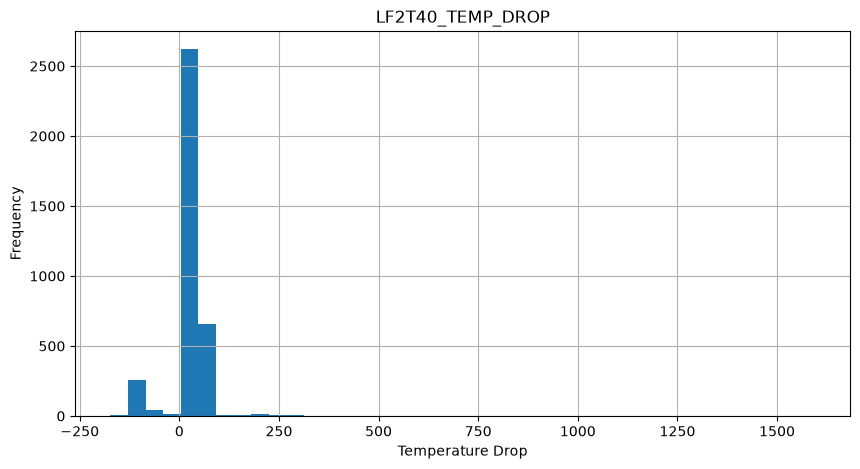

count    3643.000000
mean       29.210266
std        53.020208
min      -173.000000
25%        29.000000
50%        37.000000
75%        45.000000
max      1595.000000
Name: LF2T40_TEMP_DROP, dtype: float64


In [6]:
df[TARGET].hist(bins=40)
plt.title(TARGET)
plt.xlabel("Temperature Drop")
plt.ylabel("Frequency")
plt.show()

print(df[TARGET].describe())

## Numeric Feature Distributions

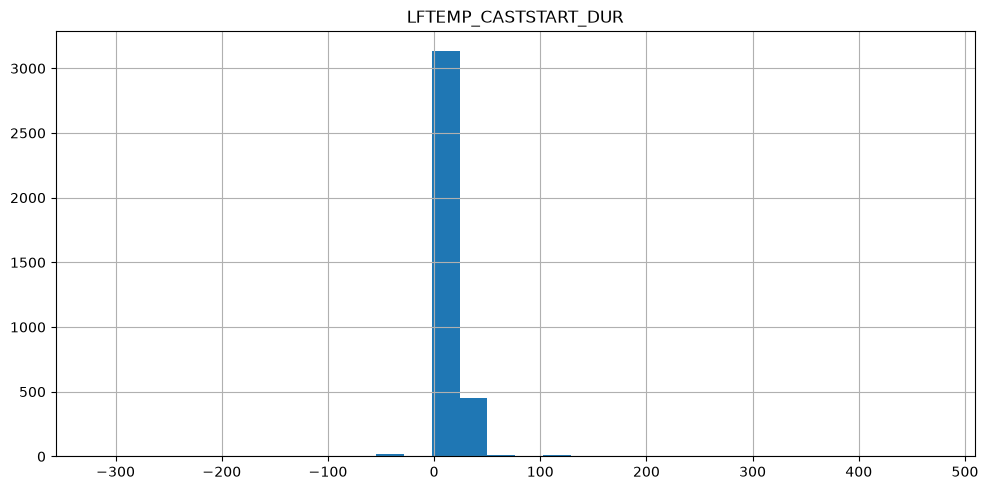

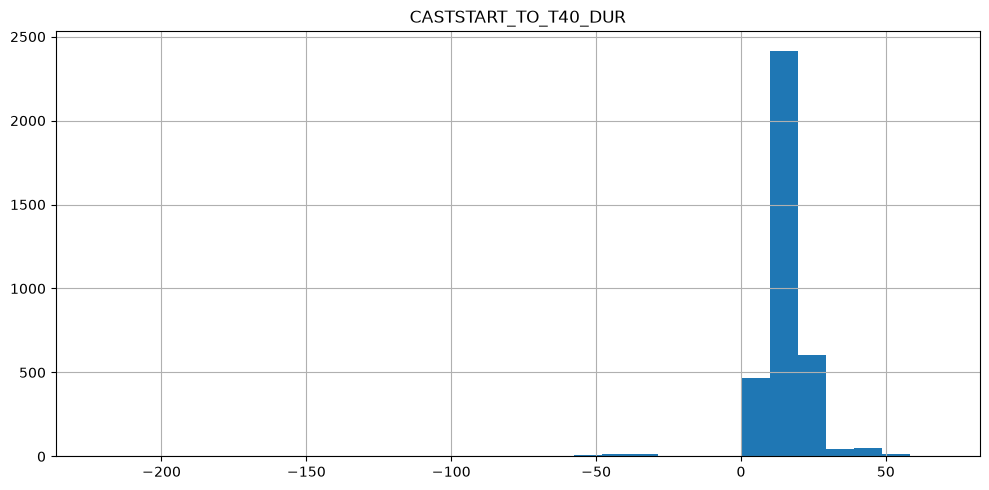

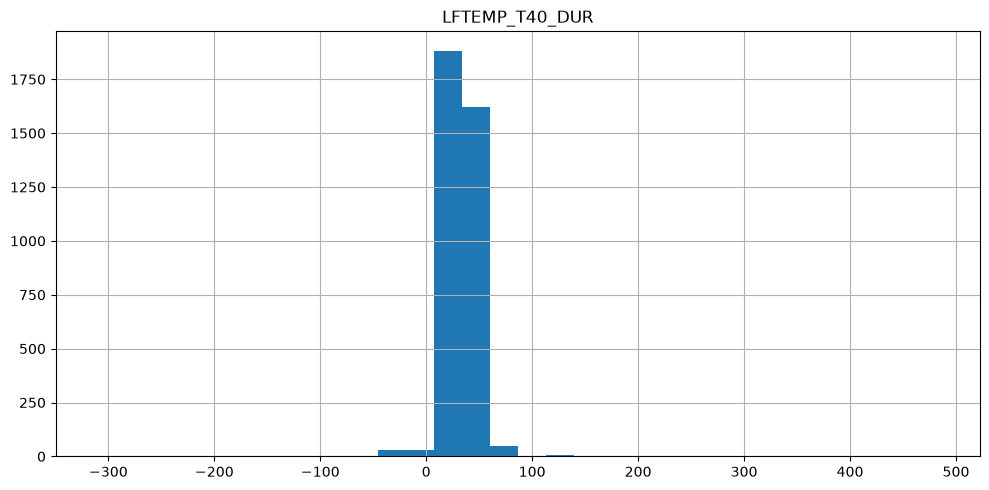

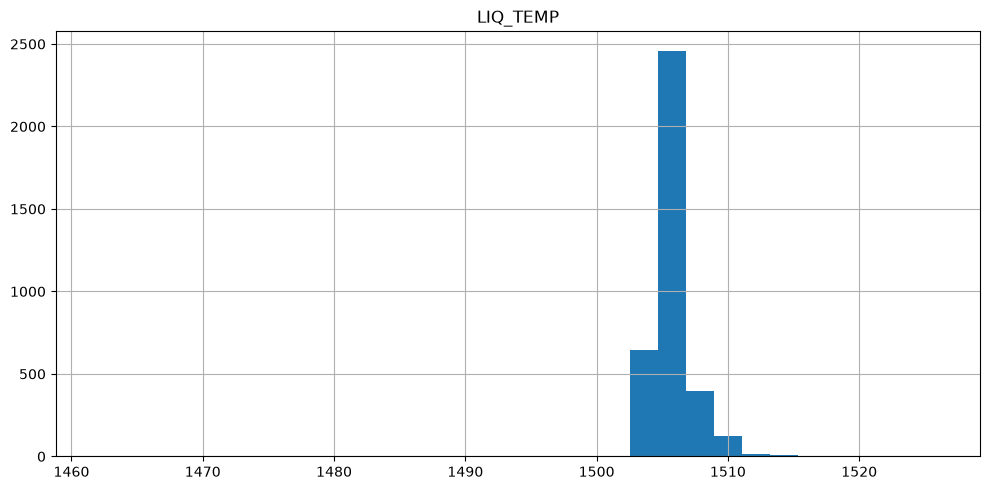

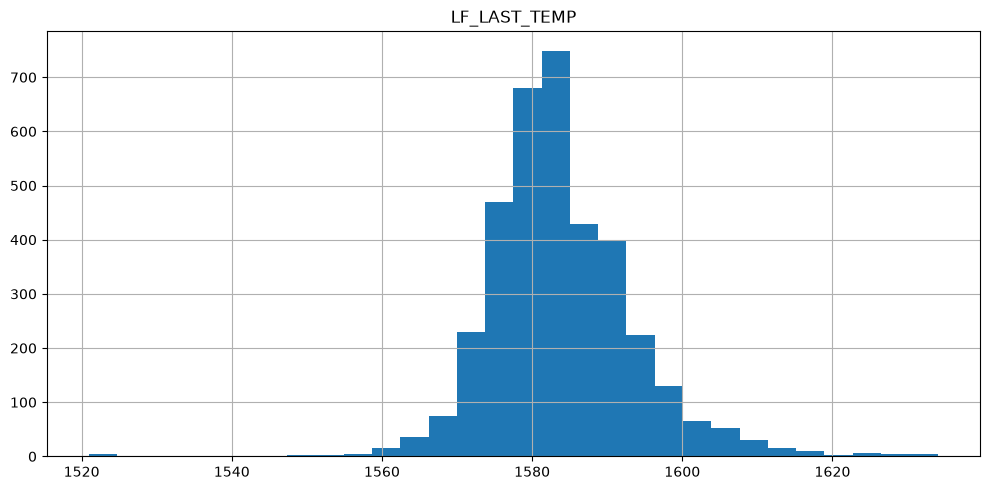

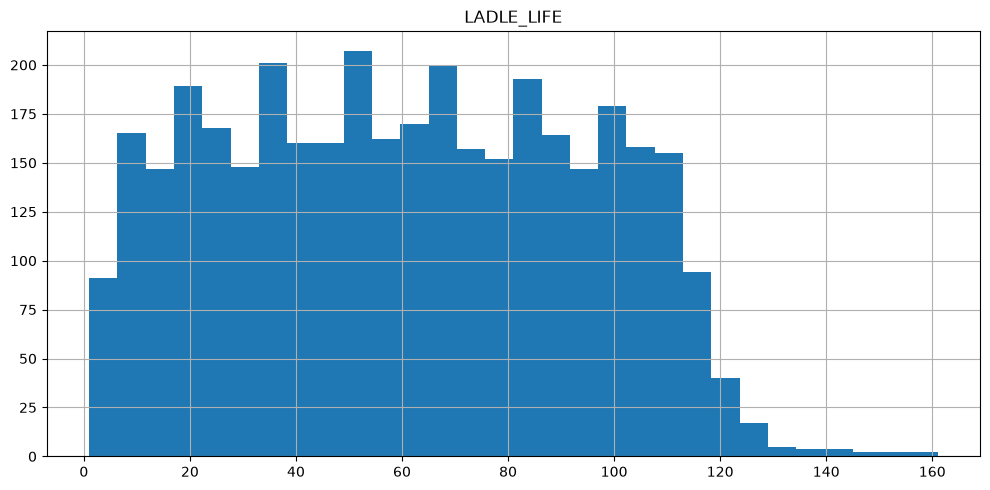

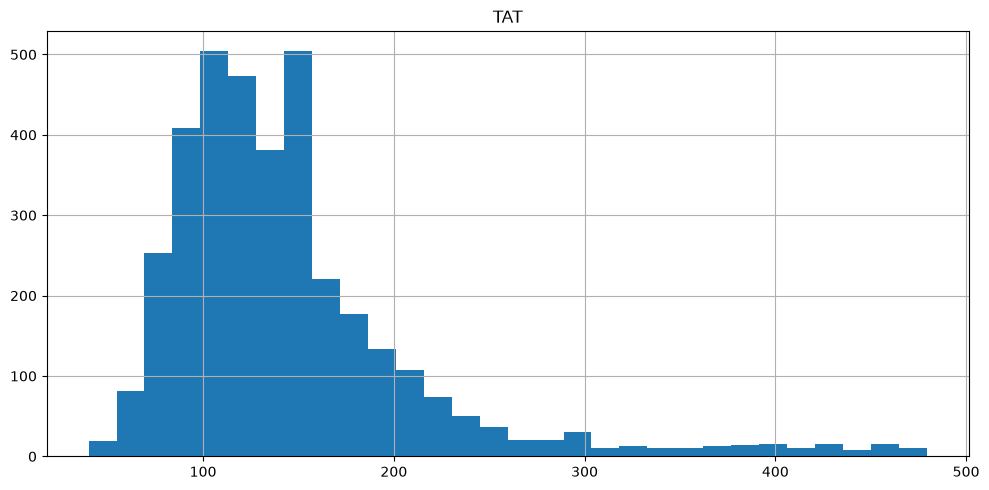

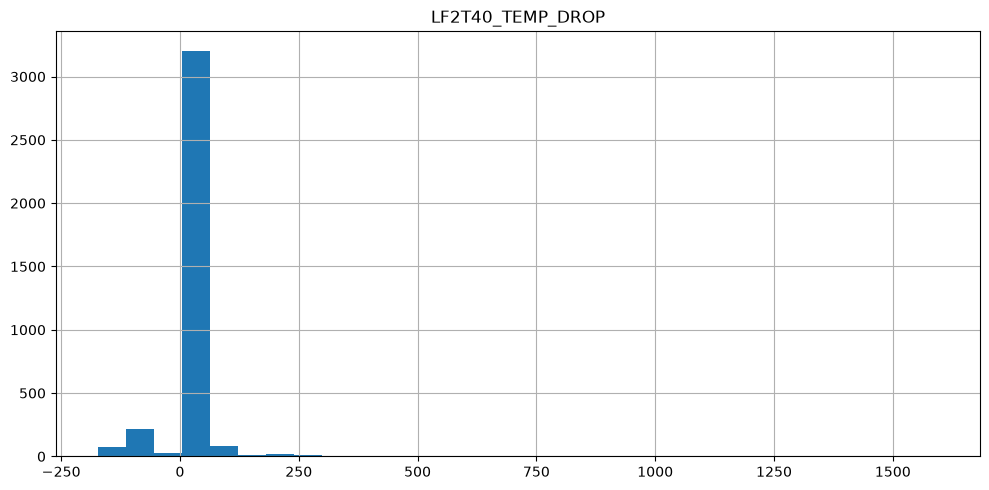

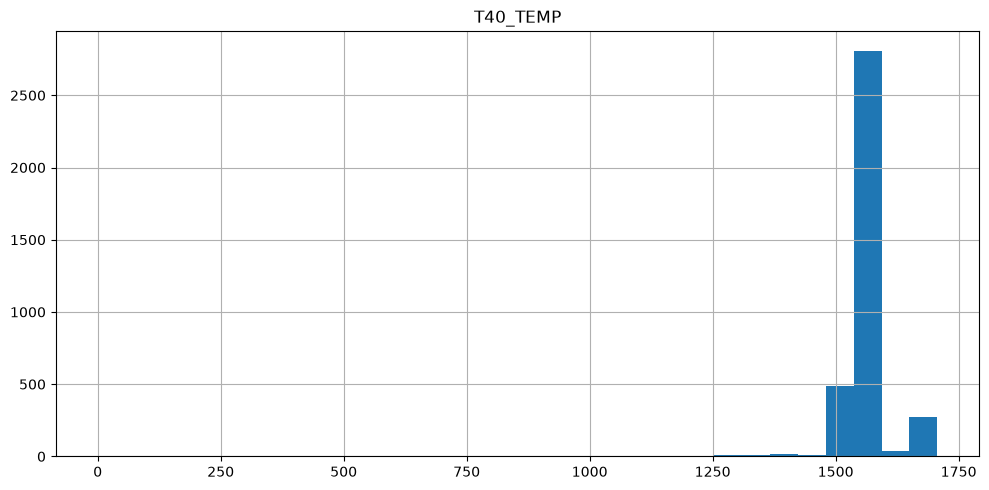

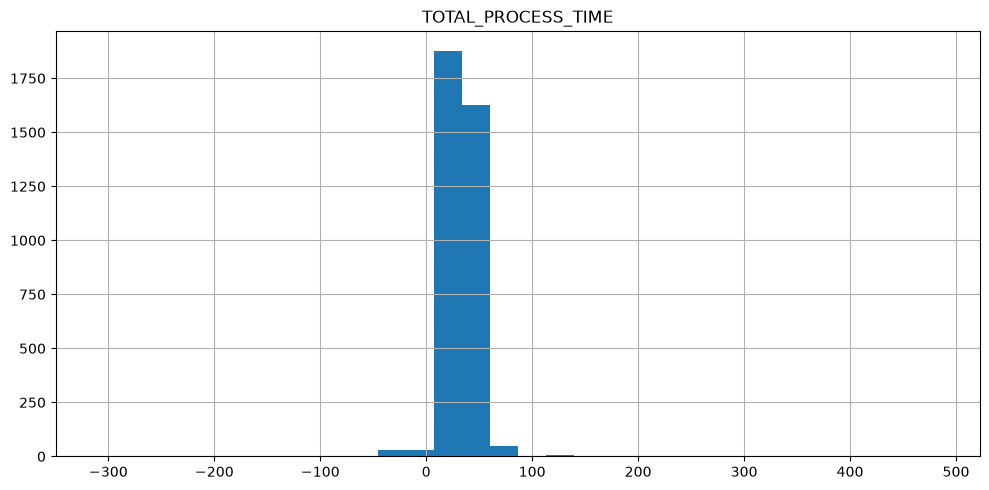

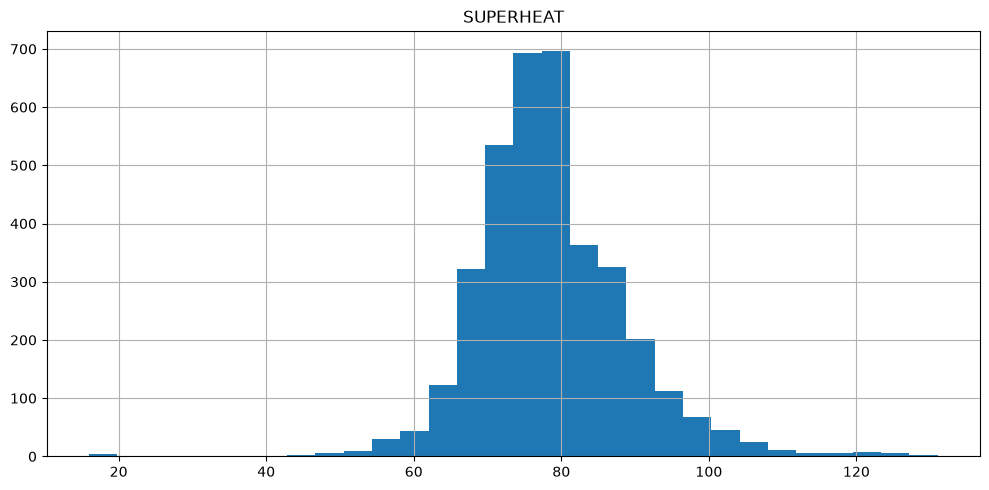

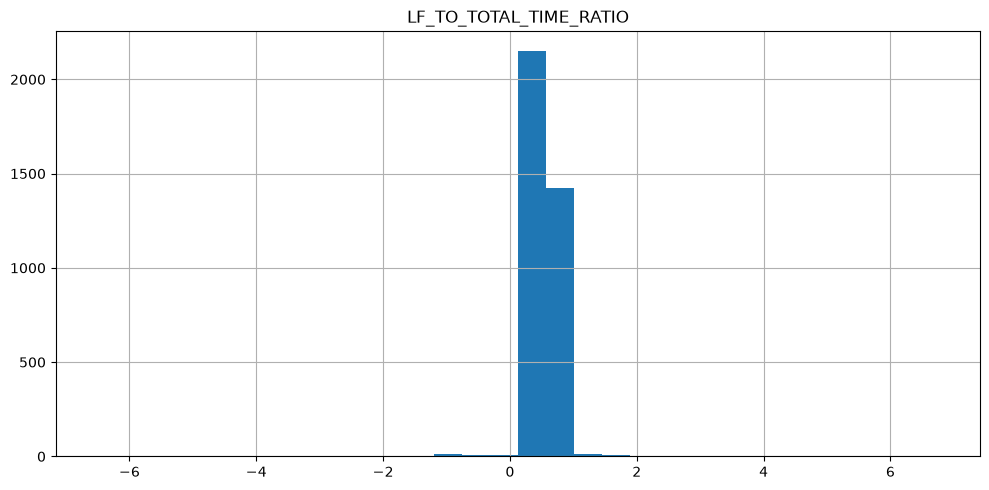

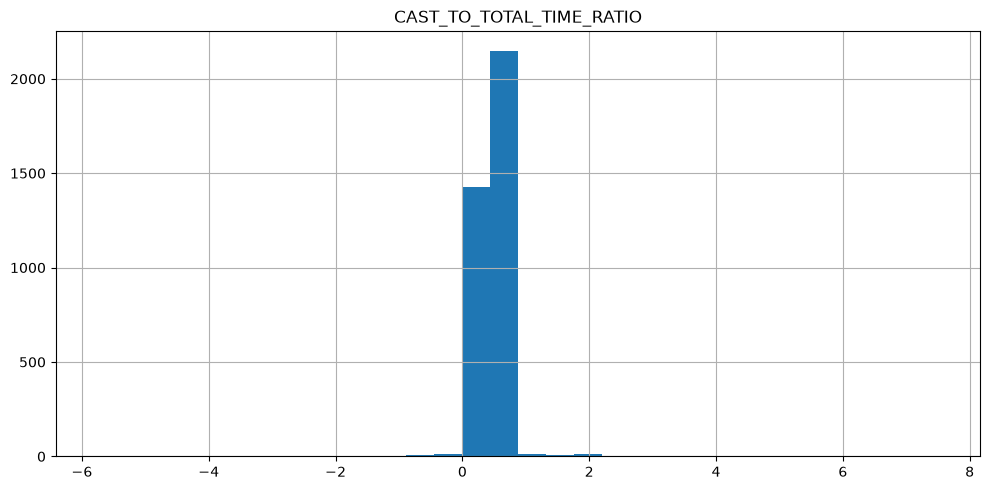

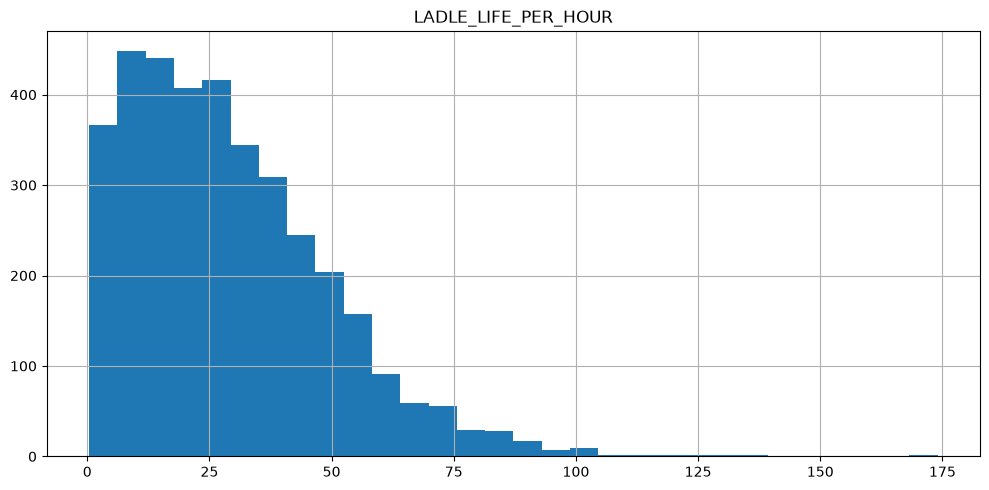

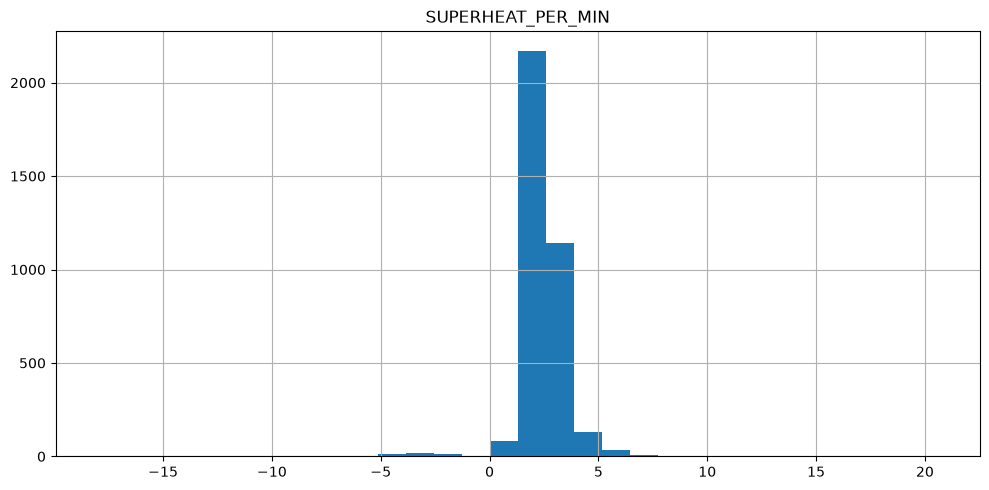

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(col)
    plt.tight_layout()
    plt.show()

## Correlation Matrix

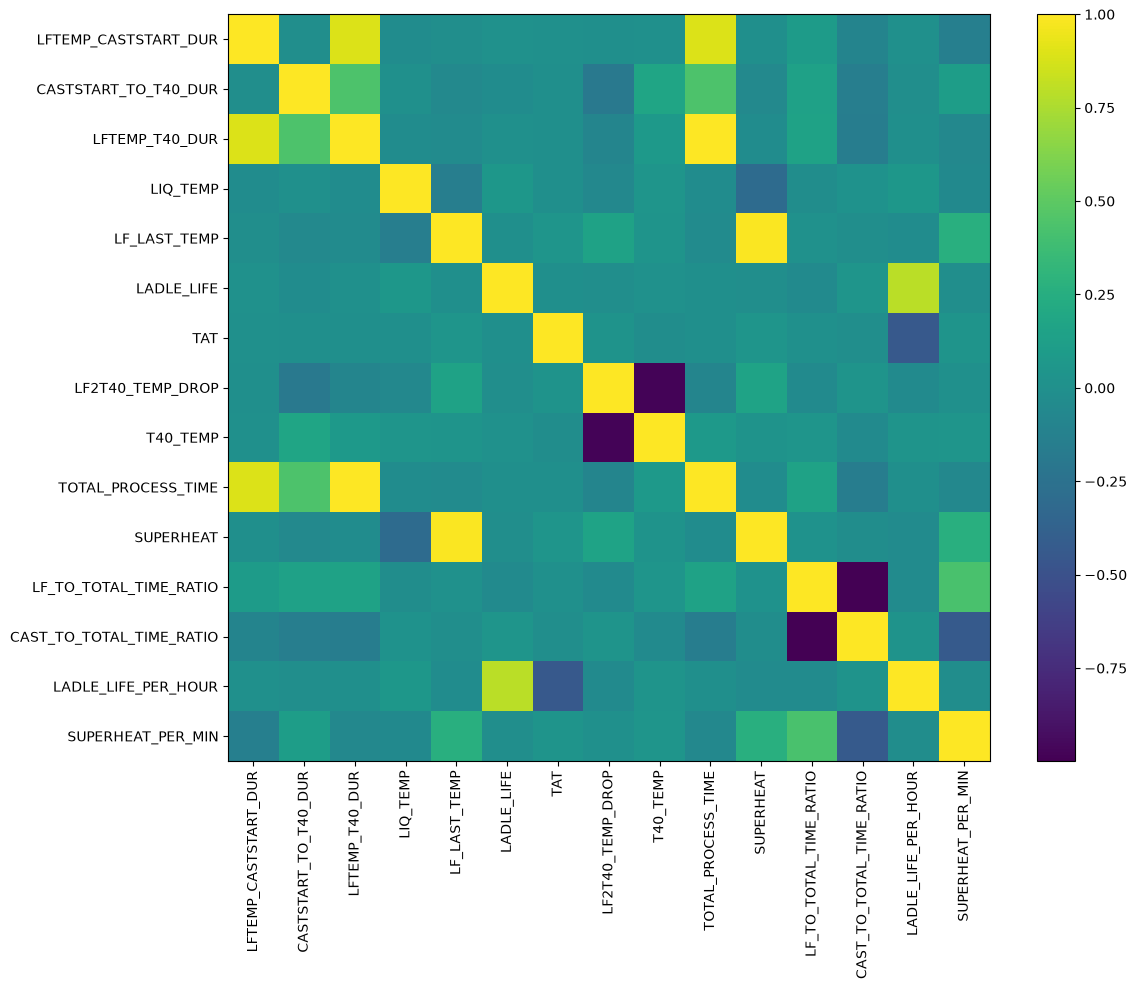

,Correlation
LF2T40_TEMP_DROP,1.000000
SUPERHEAT,0.156838
LF_LAST_TEMP,0.151464
CAST_TO_TOTAL_TIME_RATIO,0.038426
TAT,0.027330
SUPERHEAT_PER_MIN,0.005183
LFTEMP_CASTSTART_DUR,-0.003144
LADLE_LIFE,-0.012491
LF_TO_TOTAL_TIME_RATIO,-0.038425
LADLE_LIFE_PER_HOUR,-0.038952


In [8]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,10))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.tight_layout()
plt.show()

display(
corr[TARGET].sort_values(ascending=False).to_frame("Correlation")
)

## Feature vs Target

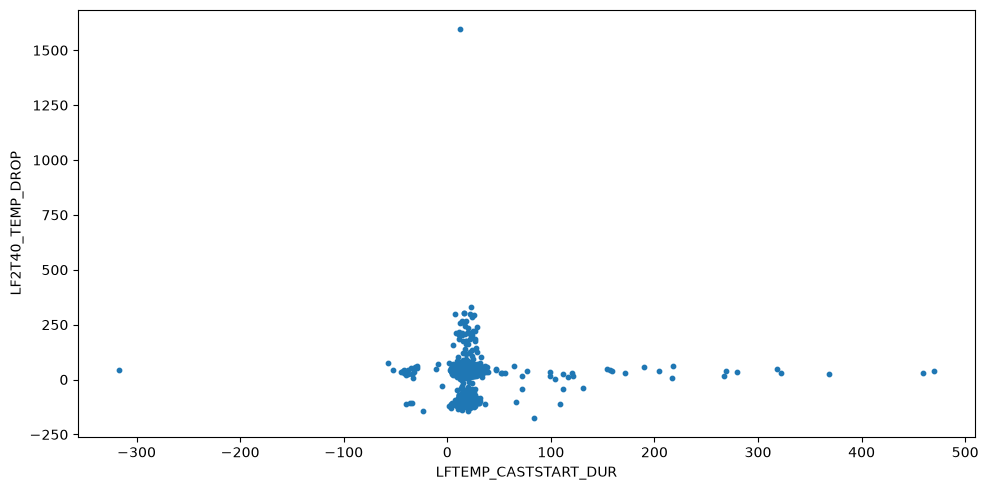

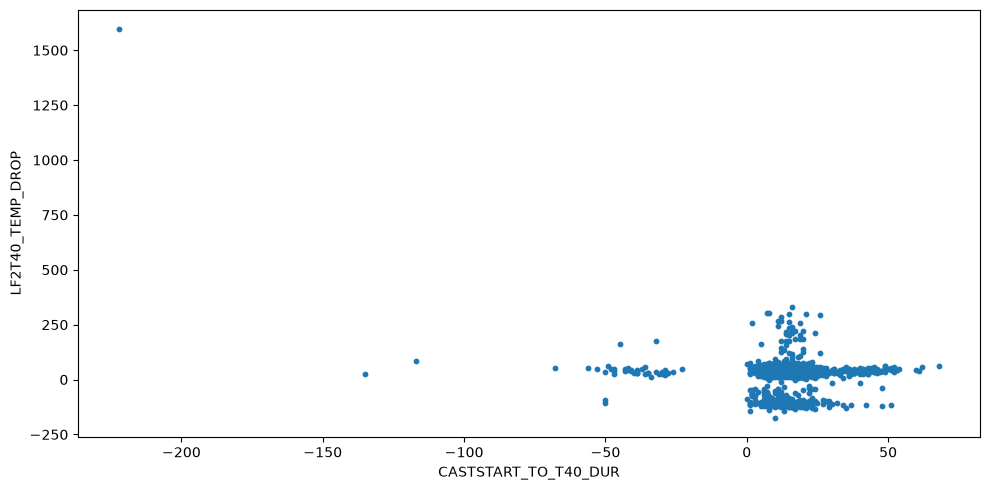

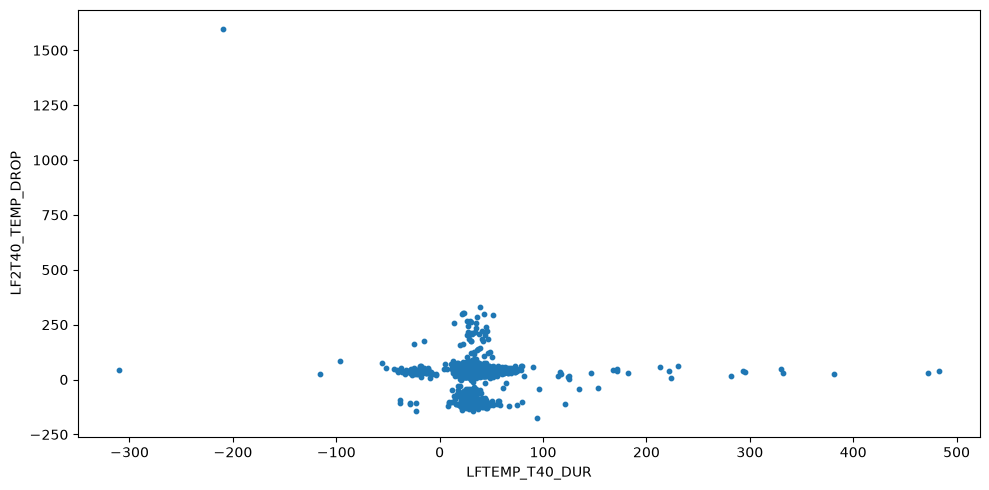

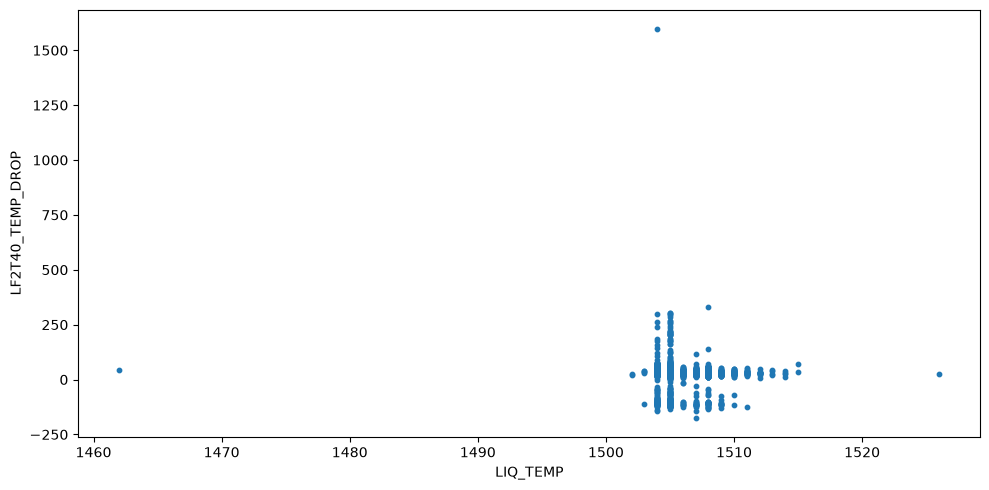

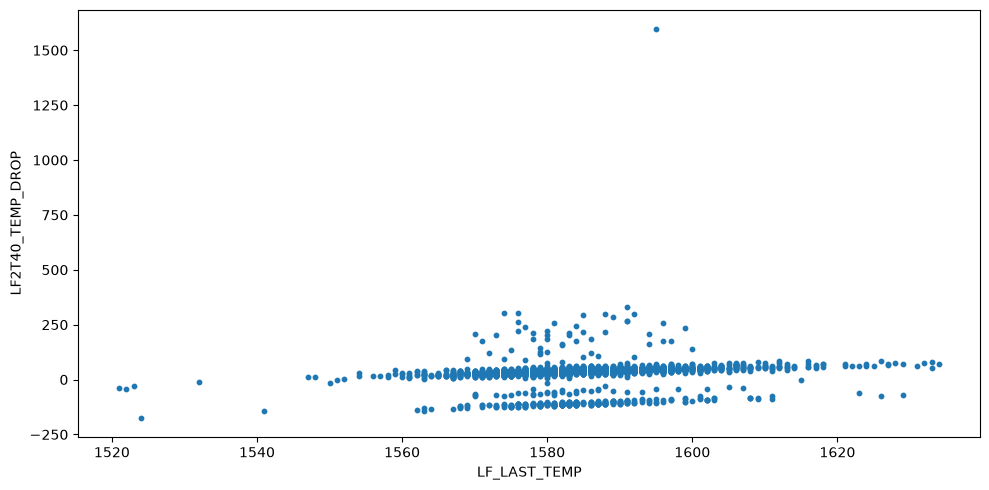

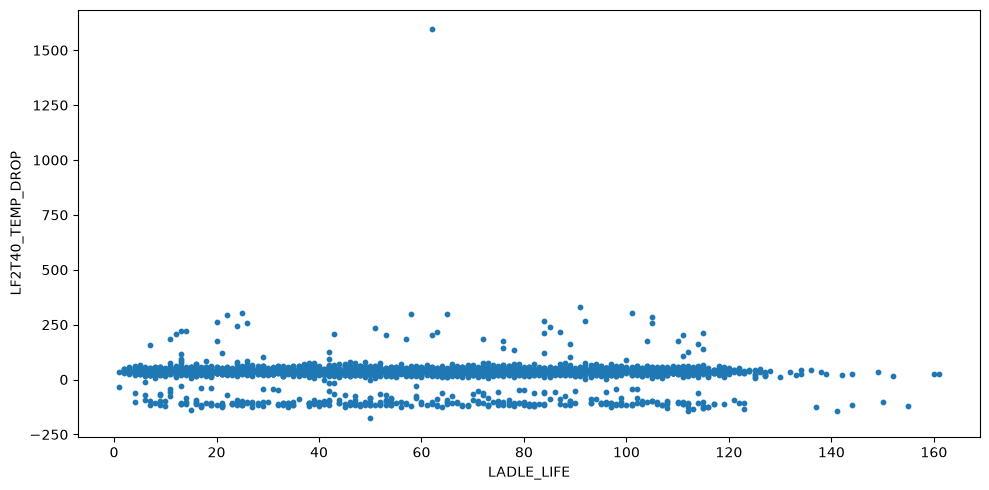

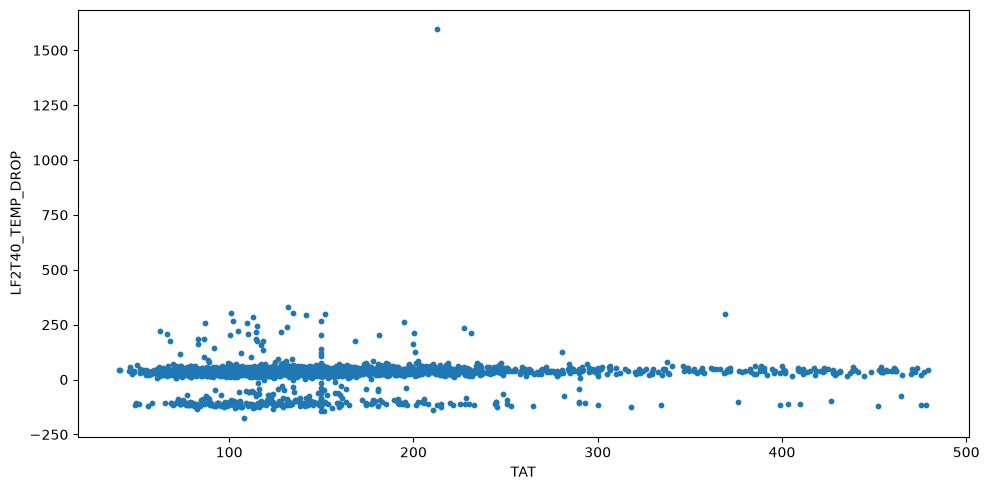

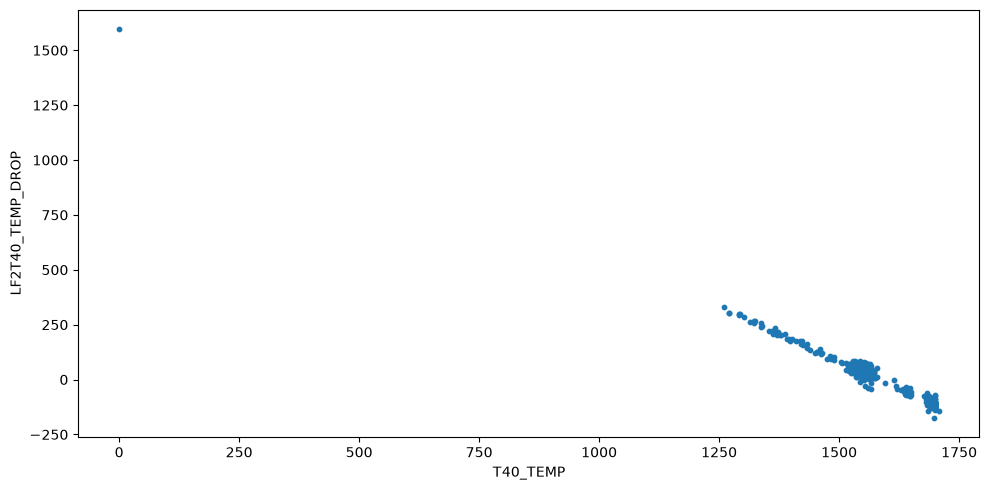

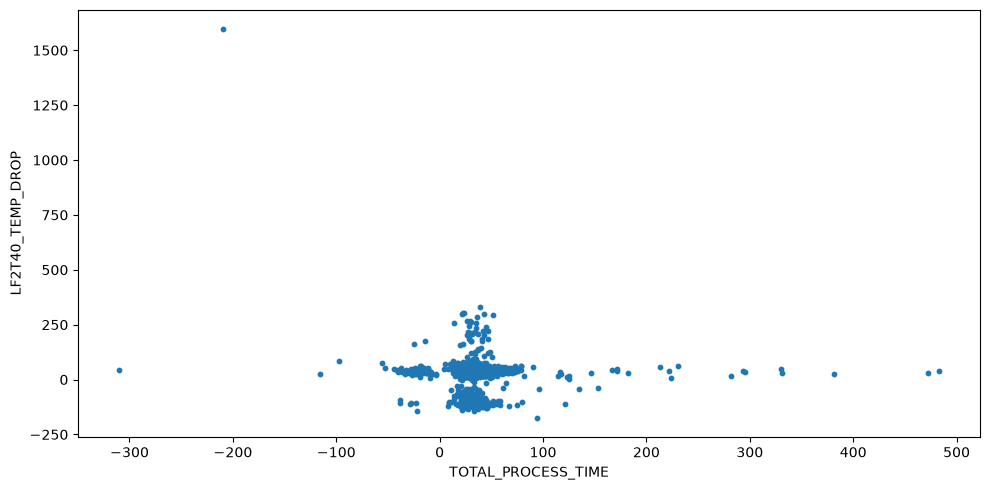

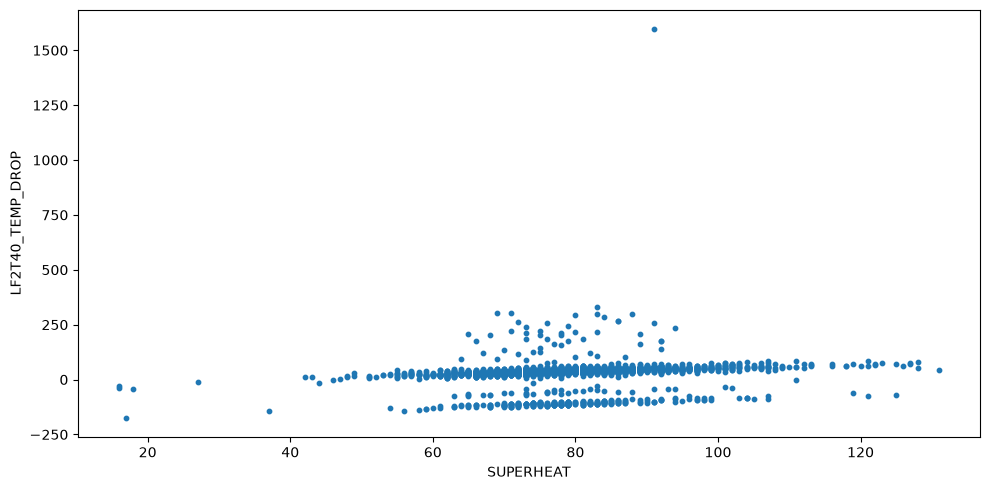

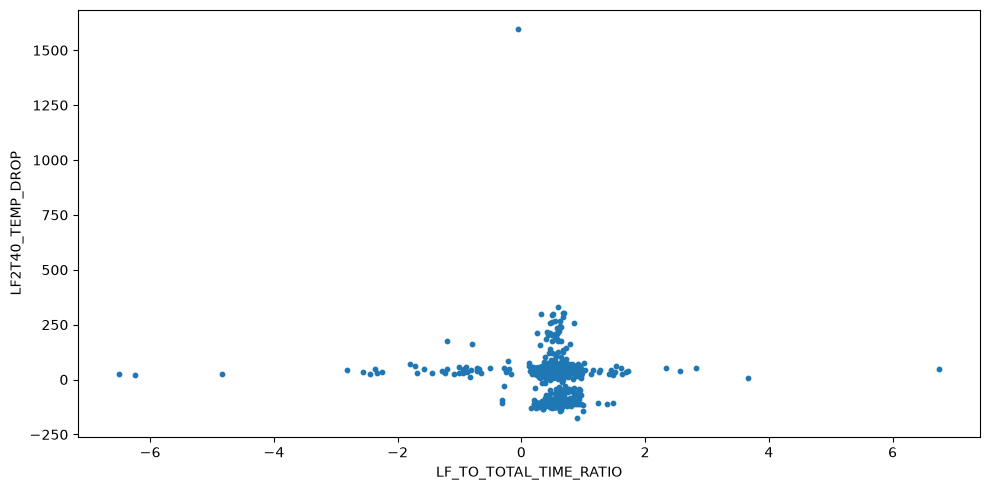

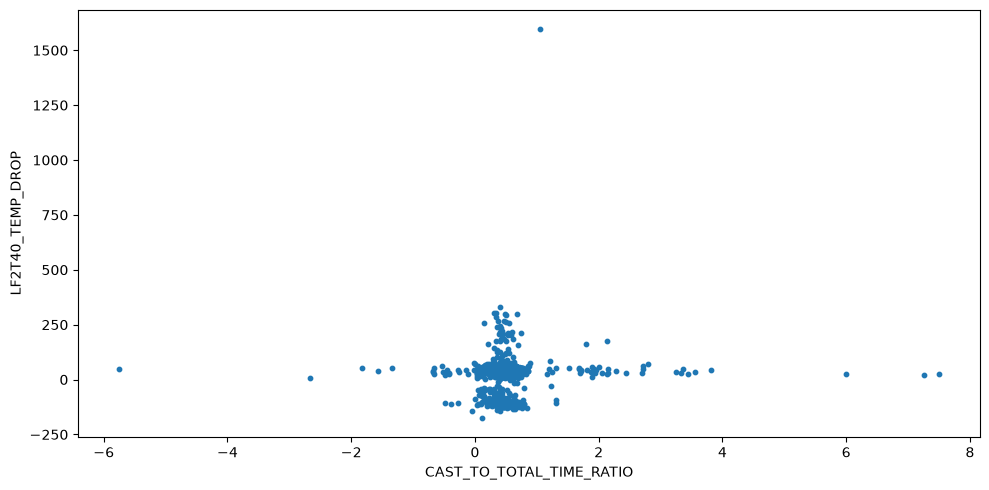

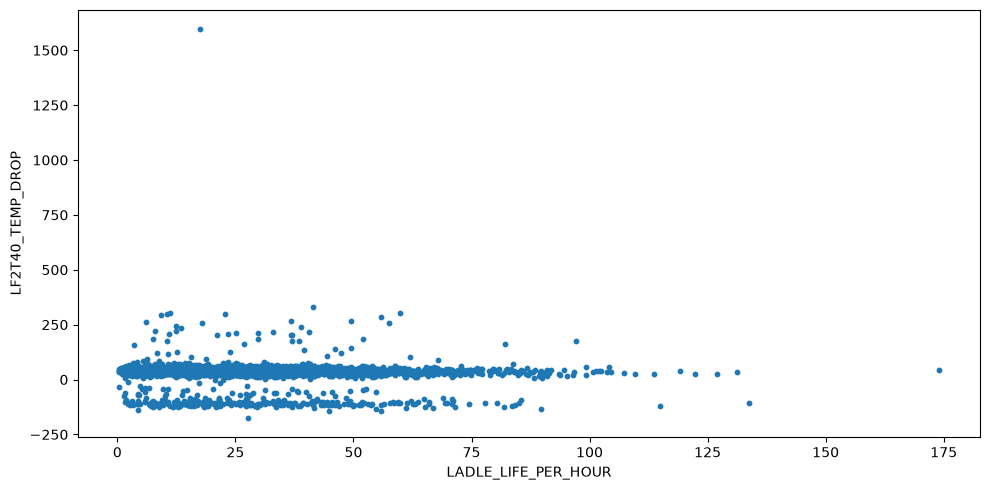

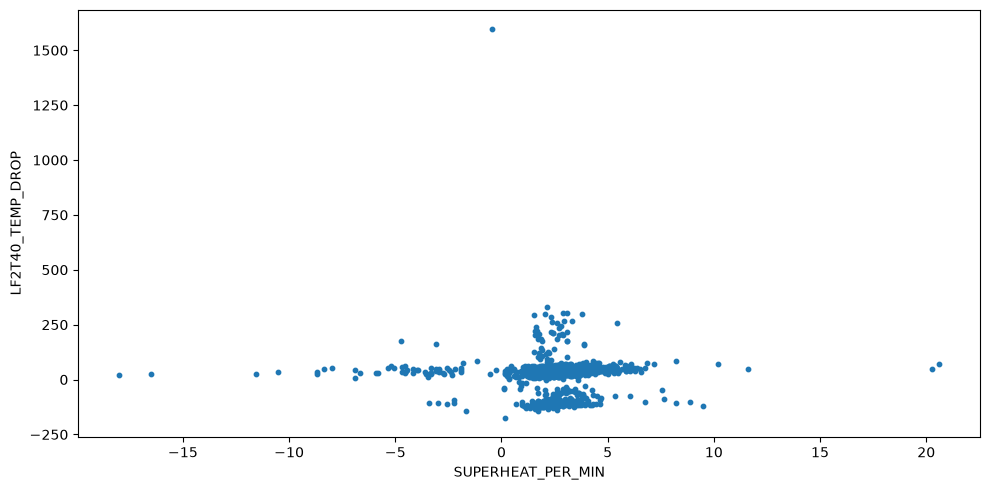

In [9]:
features=[c for c in numeric_cols if c!=TARGET]

for col in features:
    plt.figure()
    plt.scatter(df[col],df[TARGET],s=10)
    plt.xlabel(col)
    plt.ylabel(TARGET)
    plt.tight_layout()
    plt.show()

## Outlier Analysis

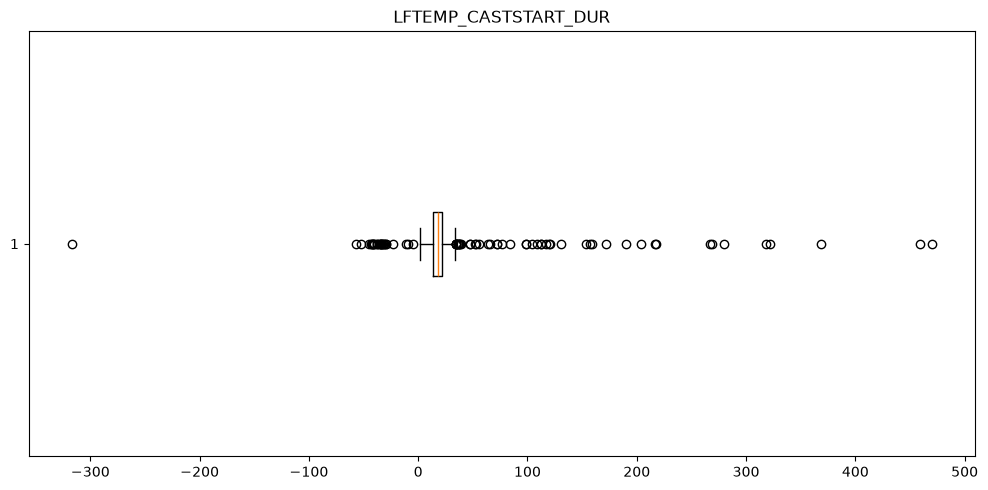

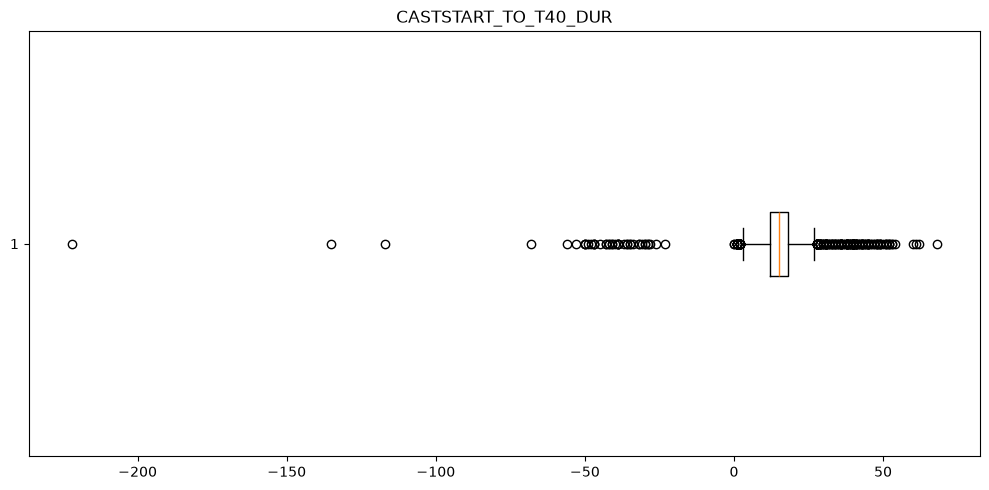

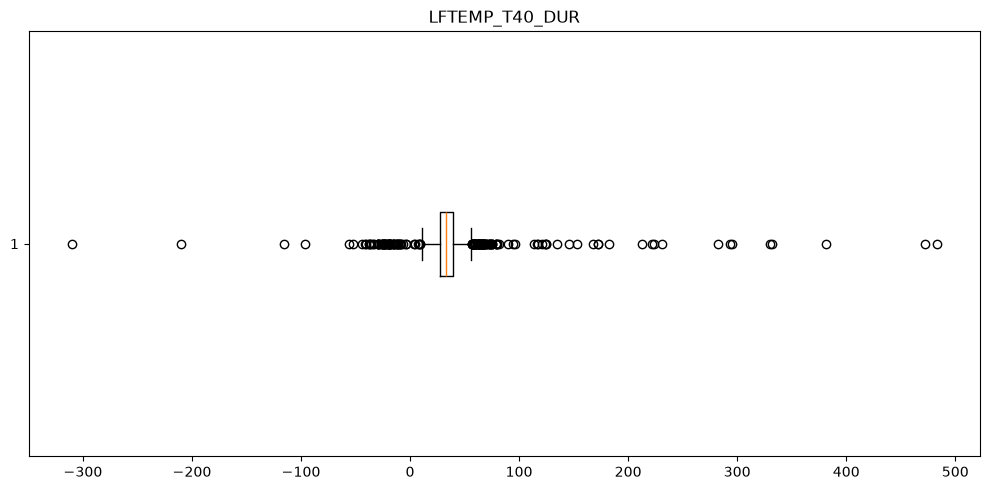

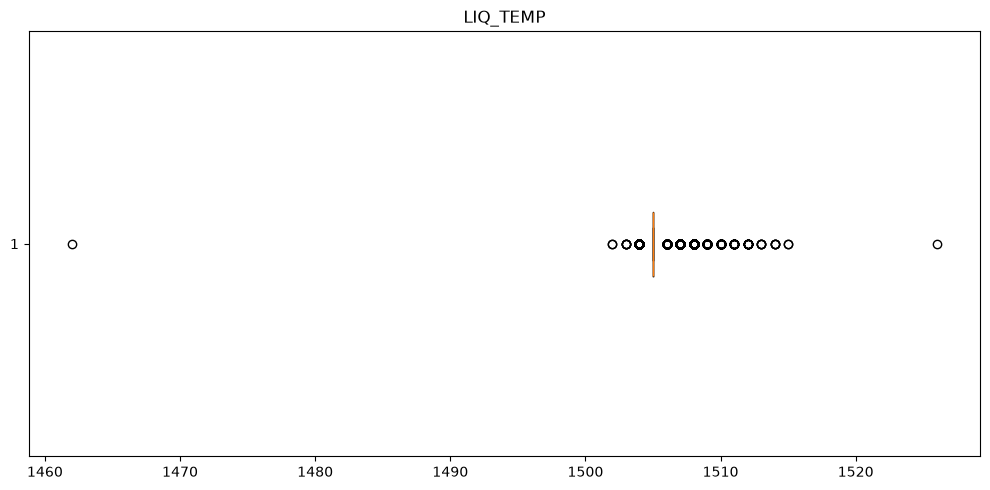

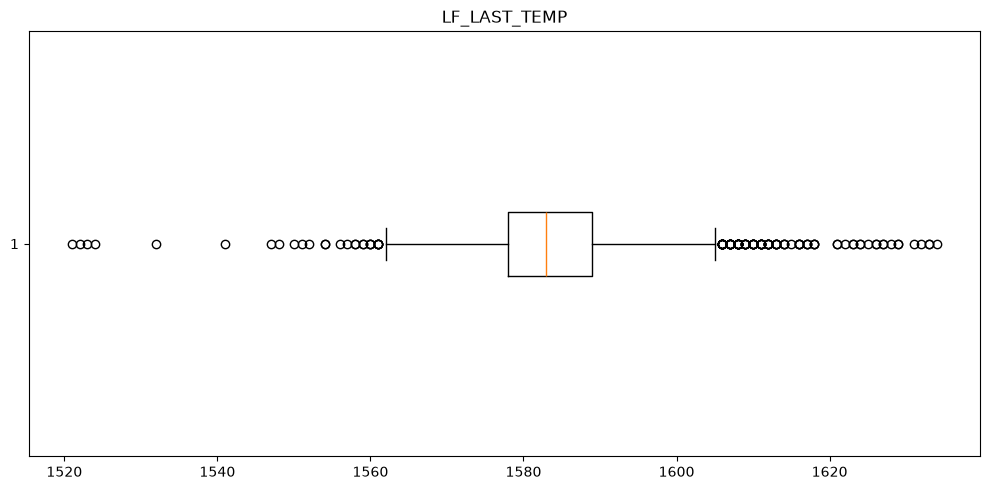

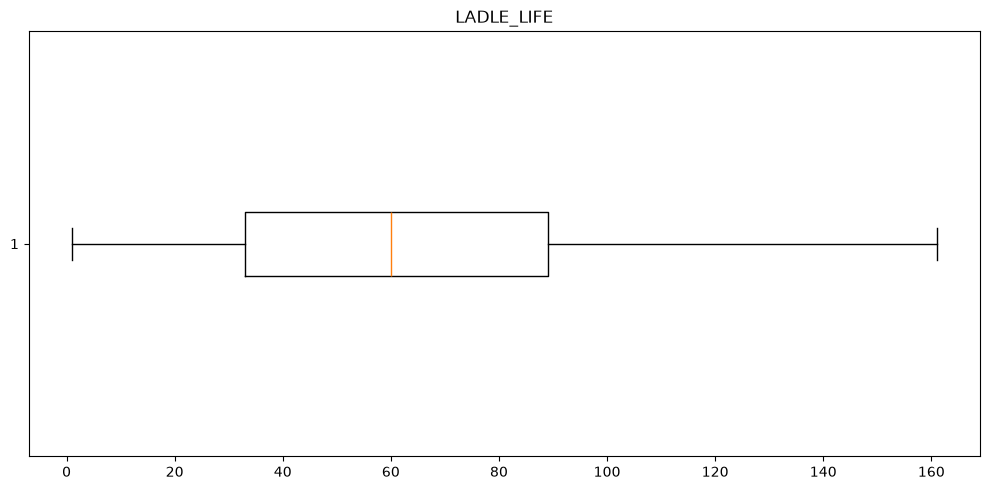

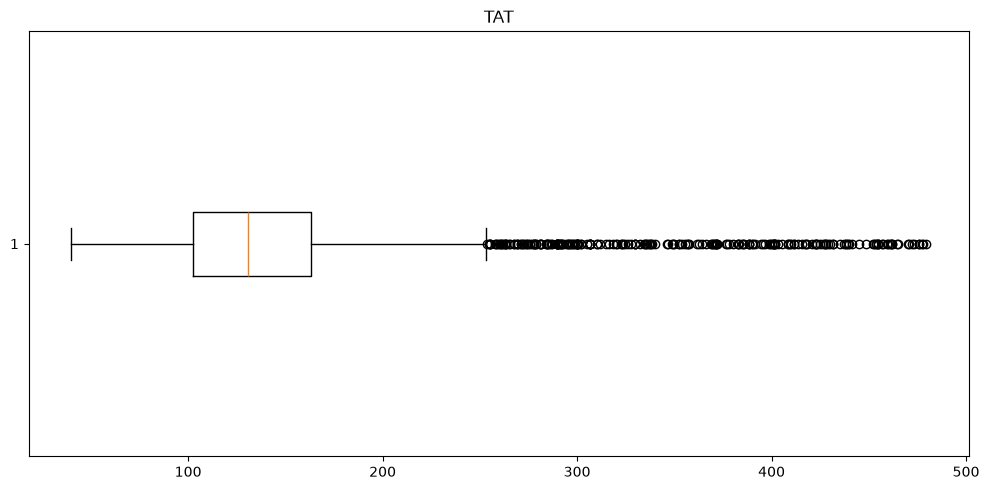

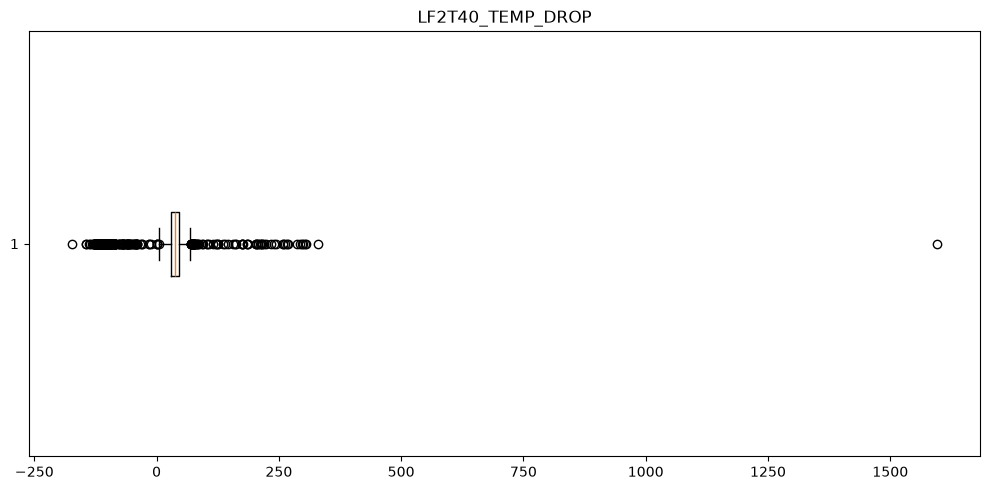

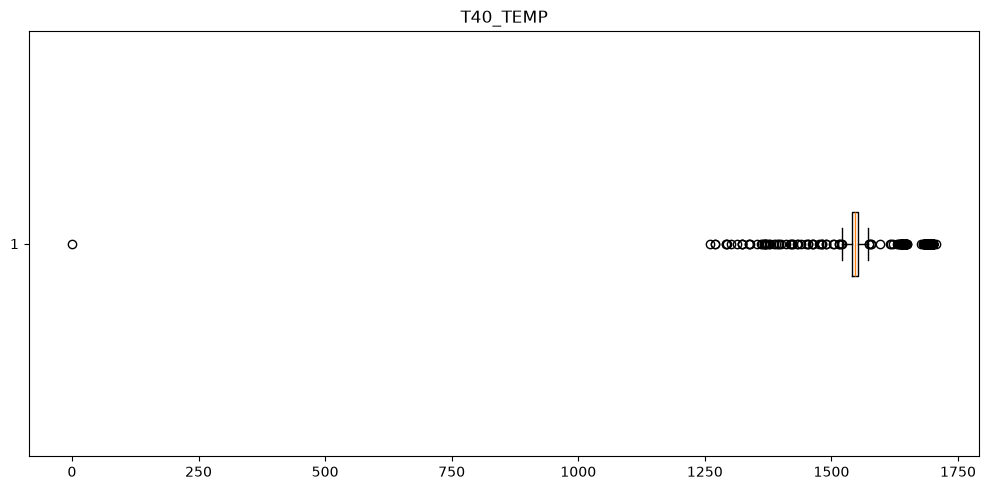

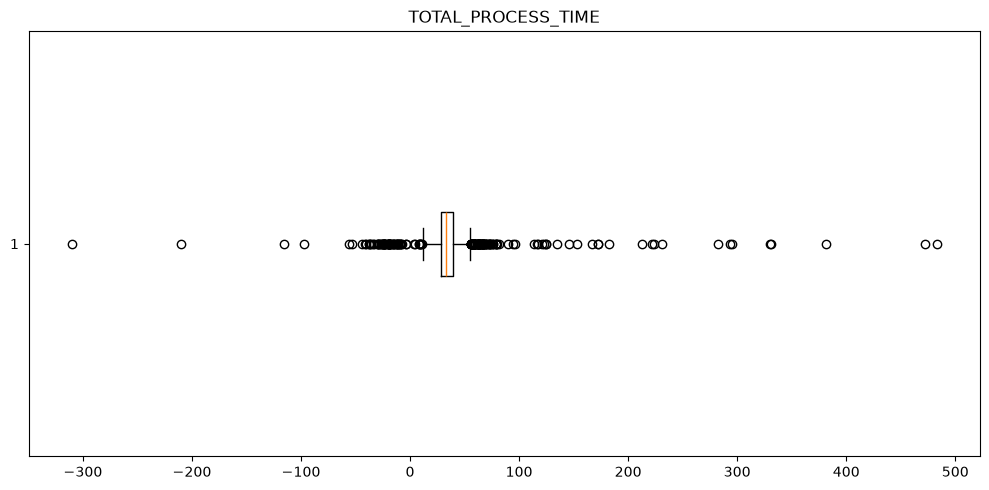

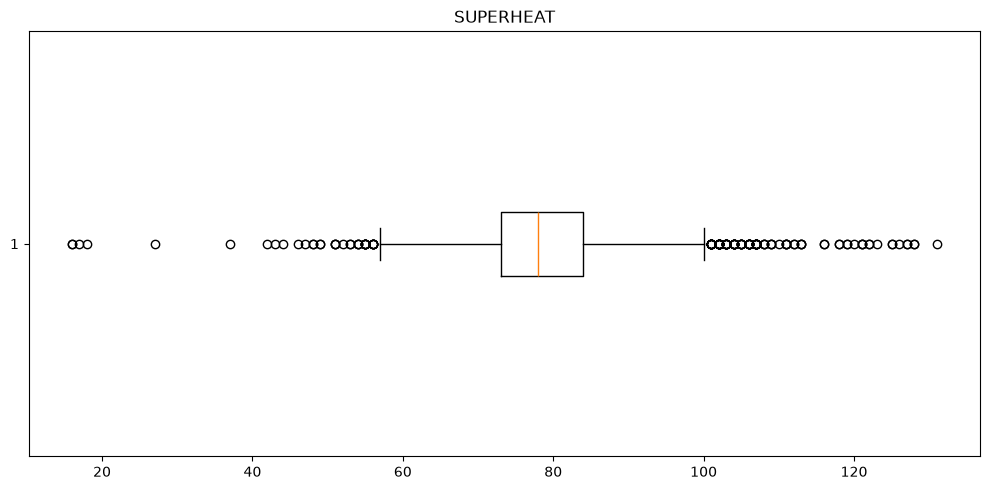

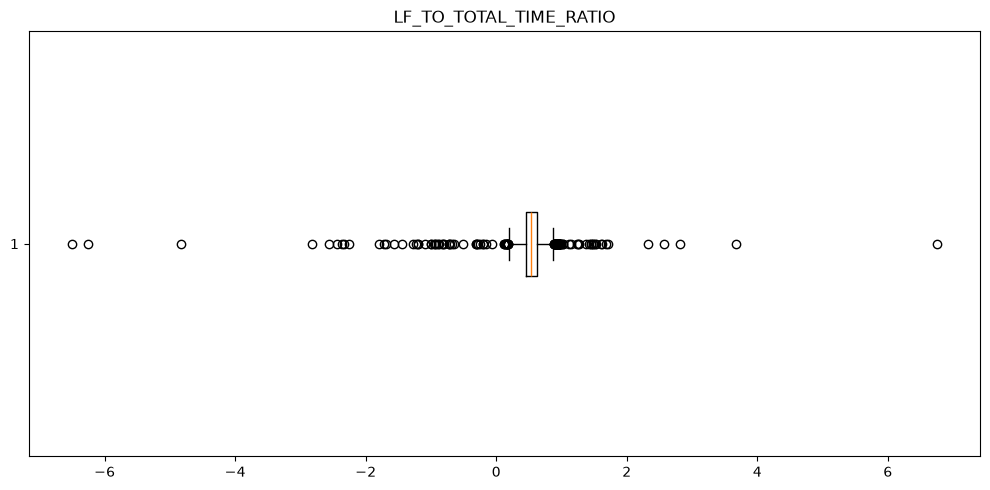

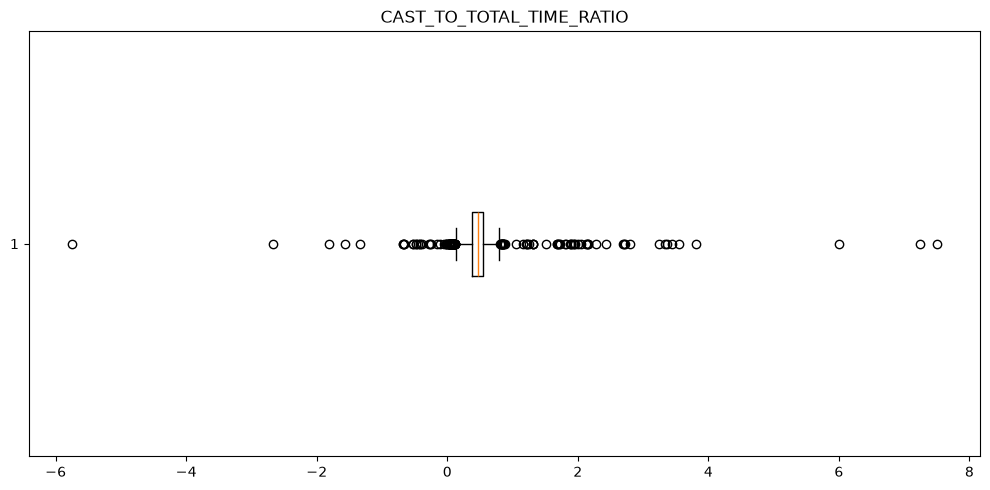

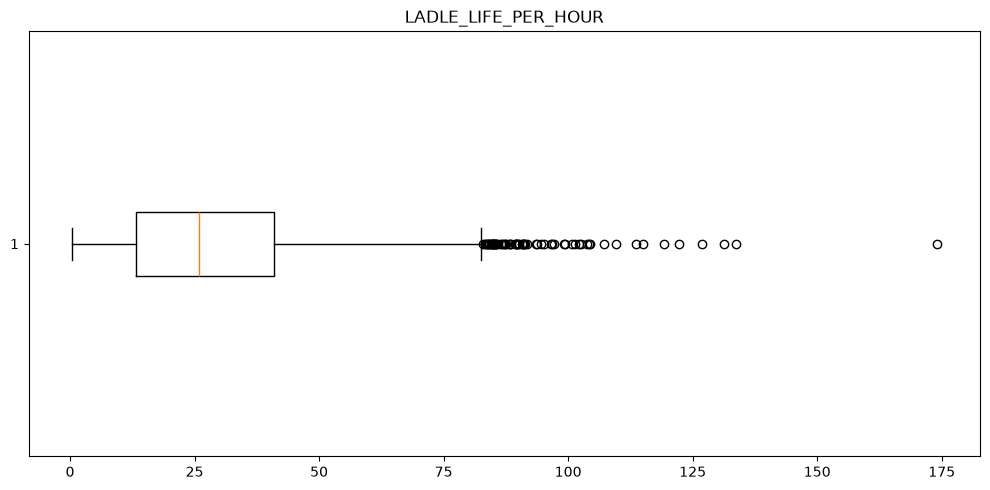

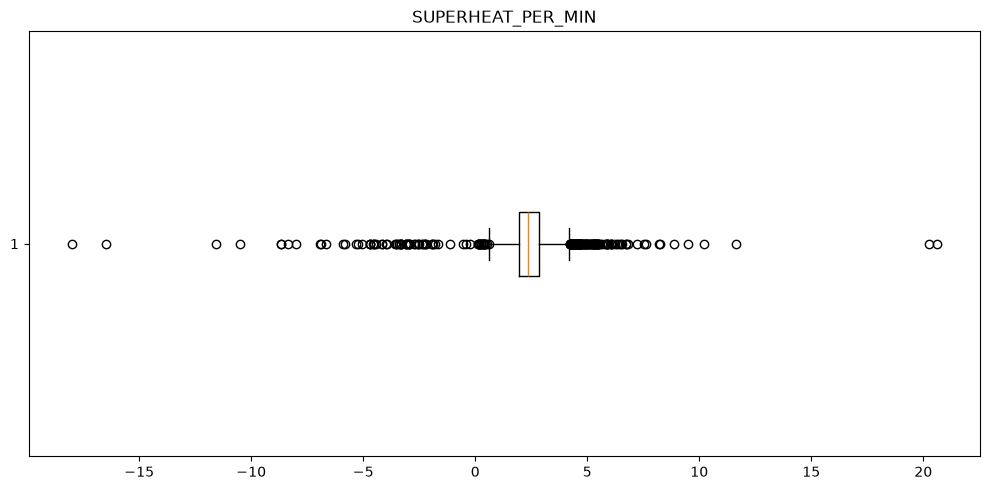

In [10]:
for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col].dropna(),vert=False)
    plt.title(col)
    plt.tight_layout()
    plt.show()

## Variance Inflation Factor (VIF)

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

feature_df=df.select_dtypes(include=np.number).drop(columns=[TARGET],errors="ignore")

vif=pd.DataFrame({
    "Feature":feature_df.columns,
    "VIF":[variance_inflation_factor(feature_df.values,i) for i in range(feature_df.shape[1])]
})

display(vif.sort_values("VIF",ascending=False))

,Feature,VIF
0,LFTEMP_CASTSTART_DUR,inf
1,CASTSTART_TO_T40_DUR,inf
3,LIQ_TEMP,inf
4,LF_LAST_TEMP,inf
8,TOTAL_PROCESS_TIME,inf
9,SUPERHEAT,inf
2,LFTEMP_T40_DUR,3.240040e+04
10,LF_TO_TOTAL_TIME_RATIO,6.451184e+03
11,CAST_TO_TOTAL_TIME_RATIO,5.680841e+03
7,T40_TEMP,9.145682e+02


## Summary

In [12]:
print("EDA completed successfully.")

EDA completed successfully.
